## Intuition:

Where KNN memorizes the whole dataset and votes locally, SVM does the opposite: it looks at the *entire* training set once, but ultimately only cares about a small subset of points — the ones closest to the opposite class — and discards the rest as irrelevant to the decision boundary. The core goal is to find the hyperplane that separates classes with the **widest possible margin**, since a wider margin generally means better generalization to unseen data (more "breathing room" before a new point crosses into the wrong side).

## Geometric Intuition:

In 2D, this is literally a line; in higher dimensions, it's a hyperplane. The hyperplane is defined by `w·x + b = 0`, and the margin boundaries sit at `w·x + b = +1` and `w·x + b = -1`. Maximizing the margin means minimizing `||w||`, subject to every point being correctly classified (or a controlled amount of violation, in the soft-margin case below).

**What happens when classes aren't linearly separable?** This is where SVM's most distinctive idea comes in — the **kernel trick**. Rather than explicitly transforming data into a higher-dimensional space (which would be computationally expensive), SVM uses a kernel function to compute what the dot product *would be* in that higher-dimensional space, without ever actually doing the transformation. This lets it draw curved decision boundaries in the original space while still solving a linear separation problem internally.

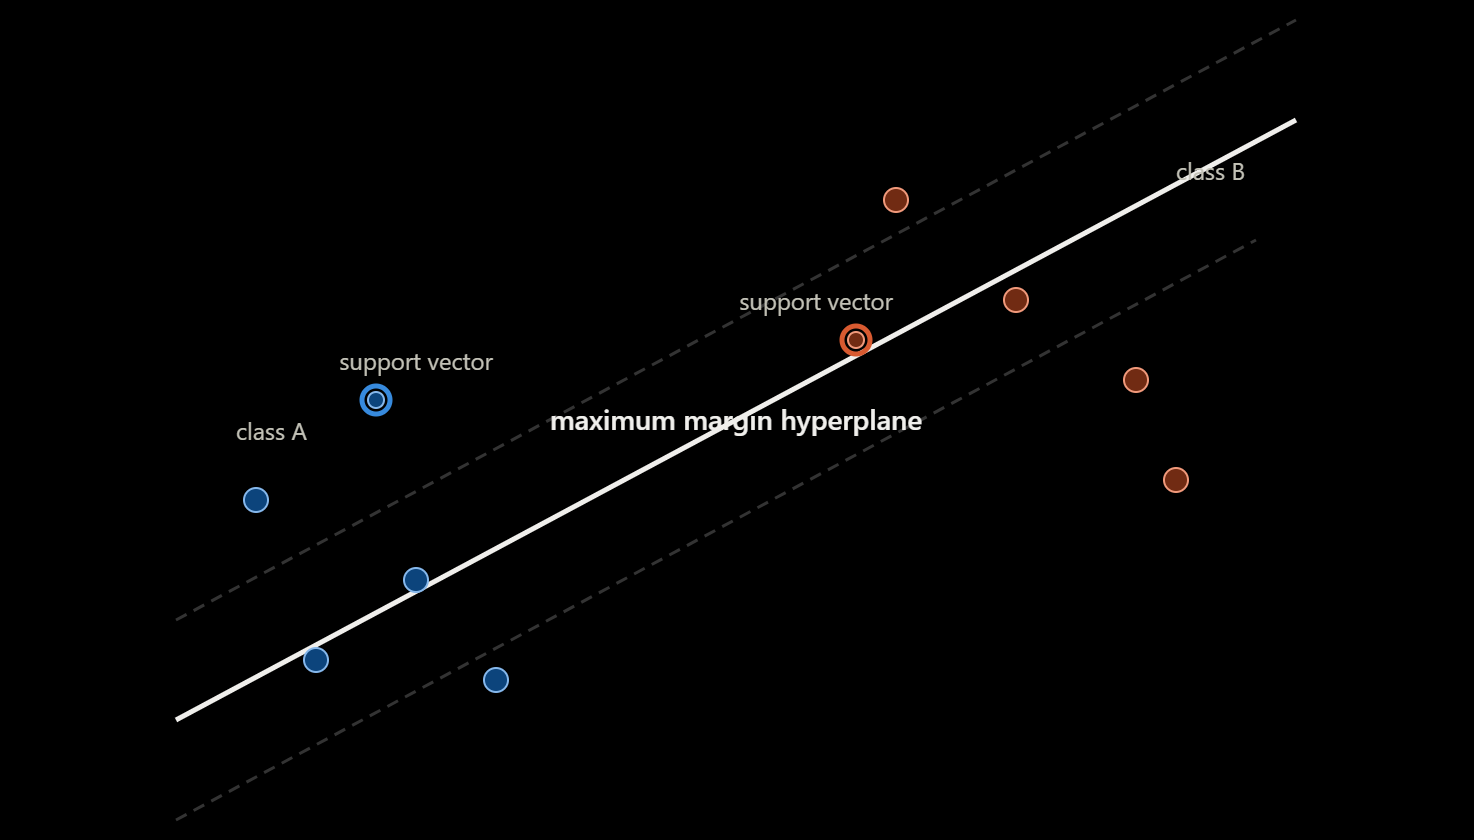

This diagram shows the entire core idea: SVM doesn't just find *any* line separating the classes — it finds the one that **maximizes the margin** (the gap between the dashed boundaries), and only the closest points from each class (the circled "support vectors") actually determine where that line sits. Every other point is irrelevant to the boundary's position.

---

## Types of SVM:

**By margin strictness:**
- **Hard Margin SVM** — requires perfect separation, no points allowed inside the margin or misclassified. Only works if data is perfectly linearly separable (rare in practice, very sensitive to outliers).
- **Soft Margin SVM** — allows some points to violate the margin (or even be misclassified), controlled by a regularization parameter `C`. This is what's actually used in practice.
  - **Large `C`** → less tolerance for margin violations → narrower margin, tighter fit → risk of overfitting
  - **Small `C`** → more tolerance → wider margin → risk of underfitting
  - This is SVM's direct analog to KNN's `k` — a single hyperparameter that governs the same overfitting/underfitting tradeoff, just through a different mechanism.

**By kernel:**
- **Linear kernel** — no transformation; used when data is (roughly) linearly separable
- **Polynomial kernel** — captures curved, polynomial-shaped boundaries
- **RBF (Radial Basis Function) / Gaussian kernel** — the most commonly used default; can model highly complex, non-linear boundaries by measuring similarity based on distance, with a `gamma` parameter controlling how far a single point's influence reaches
- **Sigmoid kernel** — less common, behaves similarly to a neural network activation function

**By task:**
- **SVC (Support Vector Classifier)** — classification, what's described above
- **SVR (Support Vector Regression)** — regression variant; instead of maximizing a margin between classes, it fits a boundary (a "tube" of tolerance ε) that most points should fall within, only penalizing points outside that tube

---

## Overfitting and Underfitting:

Two hyperparameters jointly control this:
- **`C` (regularization)** — as above: high `C` → overfitting risk (fits training data too tightly, sensitive to outliers), low `C` → underfitting risk (too much tolerance, ignores real structure)
- **`gamma` (for RBF/polynomial kernels)** — controls how far a single training point's influence reaches. High `gamma` → each point only affects its immediate neighborhood → highly wiggly, overfit boundary (similar to `k=1` in KNN). Low `gamma` → influence reaches far → overly smooth, underfit boundary (similar to large `k` in KNN).

Both are typically tuned together via grid search — which connects directly back to the `Grid Search CV` notebook already in your repo.

---

## Failure Cases of SVM:

**1. Doesn't scale well to large datasets** — training complexity is roughly quadratic to cubic in the number of samples, making it impractical for very large datasets compared to something like logistic regression or tree-based models.

**2. Sensitive to feature scaling** — same as KNN, since it relies on distances/dot products; features must be scaled before training.

**3. Choosing the right kernel and hyperparameters is non-trivial** — unlike, say, a decision tree that adapts its structure automatically, SVM performance is highly dependent on manually picking the right kernel, `C`, and `gamma` — a poor choice can drastically hurt performance.

**4. No probabilistic output by default** — SVM produces a hard classification boundary; getting calibrated probability estimates requires an extra step (Platt scaling, via `probability=True` in scikit-learn), which adds computational cost.

**5. Struggles with overlapping/noisy classes** — since it's fundamentally about margin maximization, heavily overlapping classes (common in real, noisy data) force a difficult tradeoff between margin width and misclassification tolerance, unlike probabilistic models that handle ambiguity more gracefully.

**6. Poor interpretability** — especially with non-linear kernels, it's hard to explain *why* a particular prediction was made, compared to something like a decision tree or logistic regression's coefficients.

---